In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

import transformers, sklearn, aif360
print(f"transformers : {transformers.__version__}")
print(f"sklearn      : {sklearn.__version__}")
print(f"aif360       : {aif360.__version__}")

Device: cpu
transformers : 4.44.2
sklearn      : 1.5.1
aif360       : 0.6.1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/RAI_Assignment2'

# Load eval set and Part 1 probabilities
eval_df = pd.read_csv(f'{PROJECT_DIR}/eval_df.csv')
probs   = np.load(f'{PROJECT_DIR}/eval_probs_part1.npy')
labels  = eval_df['label'].values

print(f"Eval set loaded:  {len(eval_df):,} rows")
print(f"Probs loaded:     {len(probs):,} values")
print(f"Probability range: {probs.min():.4f} – {probs.max():.4f}")
print(f"Label distribution: {dict(pd.Series(labels).value_counts().sort_index())}")

Mounted at /content/drive
Eval set loaded:  20,000 rows
Probs loaded:     20,000 values
Probability range: 0.0004 – 0.9947
Label distribution: {0: 18401, 1: 1599}


In [4]:
identity_cols = ['black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian']

print("Identity column availability in eval_df:")
for col in identity_cols:
    if col in eval_df.columns:
        non_null = eval_df[col].notna().sum()
        print(f"  [OK]      {col:35s} non-null: {non_null:,}")
    else:
        print(f"  [MISSING] {col}")

Identity column availability in eval_df:
  [OK]      black                               non-null: 4,561
  [OK]      white                               non-null: 4,561
  [OK]      muslim                              non-null: 4,561
  [OK]      jewish                              non-null: 4,561
  [OK]      homosexual_gay_or_lesbian           non-null: 4,561


In [5]:
# High-black cohort: comments annotators associated with Black identity
mask_black = eval_df['black'] >= 0.5

# Reference cohort: White identity, explicitly not Black identity
mask_ref = (eval_df['white'] >= 0.5) & (eval_df['black'] < 0.1)

high_black_df = eval_df[mask_black].copy()
ref_df        = eval_df[mask_ref].copy()

high_black_probs  = probs[mask_black.values]
ref_probs         = probs[mask_ref.values]

high_black_labels = labels[mask_black.values]
ref_labels        = labels[mask_ref.values]

print("=" * 45)
print("COHORT SIZES")
print("=" * 45)
print(f"High-black cohort : {len(high_black_df):,} rows")
print(f"Reference cohort  : {len(ref_df):,} rows")
print()
print(f"High-black toxic rate : {high_black_labels.mean()*100:.1f}%")
print(f"Reference  toxic rate : {ref_labels.mean()*100:.1f}%")

if len(high_black_df) < 50:
    print("\nWARNING: High-black cohort is very small — check identity column values")
    print(eval_df['black'].describe())

COHORT SIZES
High-black cohort : 164 rows
Reference cohort  : 196 rows

High-black toxic rate : 27.4%
Reference  toxic rate : 27.0%


In [6]:
THRESHOLD = 0.4   # must match the threshold you chose in Part 1

def cohort_metrics(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    TN, FP, FN, TP = cm.ravel()

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0   # sensitivity / recall
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0   # fall-out
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0   # miss rate
    PREC = TP / (TP + FP) if (TP + FP) > 0 else 0.0  # precision

    return {
        'cohort':    name,
        'n':         len(y_true),
        'n_toxic':   int(y_true.sum()),
        'TPR':       TPR,
        'FPR':       FPR,
        'FNR':       FNR,
        'Precision': PREC,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP
    }

metrics_black = cohort_metrics(high_black_labels, high_black_probs, THRESHOLD, 'High-black')
metrics_ref   = cohort_metrics(ref_labels,         ref_probs,        THRESHOLD, 'Reference (white)')

# Disparate Impact ratio
DI = metrics_black['FPR'] / metrics_ref['FPR'] if metrics_ref['FPR'] > 0 else float('inf')

print("=" * 55)
print("PER-COHORT METRICS")
print("=" * 55)
print(f"{'Metric':<20} {'High-black':>15} {'Reference':>15}")
print("-" * 55)
for key in ['n', 'n_toxic', 'TPR', 'FPR', 'FNR', 'Precision']:
    v1 = metrics_black[key]
    v2 = metrics_ref[key]
    if isinstance(v1, float):
        print(f"  {key:<18} {v1:>15.4f} {v2:>15.4f}")
    else:
        print(f"  {key:<18} {v1:>15,} {v2:>15,}")
print("-" * 55)
print(f"  {'Disparate Impact':<18} {DI:>15.4f}  (FPR ratio: high-black / reference)")
print()
if DI > 1.0:
    print(f"  → Model over-flags high-black cohort by {DI:.2f}x")
elif DI < 1.0:
    print(f"  → Model under-flags high-black cohort (ratio < 1)")
else:
    print(f"  → No disparity detected in FPR")

PER-COHORT METRICS
Metric                    High-black       Reference
-------------------------------------------------------
  n                              164             196
  n_toxic                         45              53
  TPR                         0.6000          0.6226
  FPR                         0.1345          0.0839
  FNR                         0.4000          0.3774
  Precision                   0.6279          0.7333
-------------------------------------------------------
  Disparate Impact            1.6022  (FPR ratio: high-black / reference)

  → Model over-flags high-black cohort by 1.60x


In [7]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

def make_aif360_dataset(df_cohort, y_true, y_pred, group_col, privileged_val):
    """Build AIF360 BinaryLabelDataset from arrays."""
    tmp = pd.DataFrame({
        'label':     y_true,
        'predicted': y_pred,
        group_col:   privileged_val   # single cohort, all same group value
    })
    ds = BinaryLabelDataset(
        df=tmp,
        label_names=['label'],
        protected_attribute_names=[group_col]
    )
    return ds

# Build predictions arrays
hb_preds  = (high_black_probs >= THRESHOLD).astype(int)
ref_preds = (ref_probs        >= THRESHOLD).astype(int)

# Combine both cohorts into one AIF360 dataset for comparison
combined_df = pd.DataFrame({
    'label':     np.concatenate([high_black_labels, ref_labels]),
    'predicted': np.concatenate([hb_preds, ref_preds]),
    'group':     np.concatenate([
        np.ones(len(high_black_labels)),   # 1 = high-black (unprivileged)
        np.zeros(len(ref_labels))          # 0 = reference  (privileged)
    ])
})

dataset_true = BinaryLabelDataset(
    df=combined_df[['label', 'group']],
    label_names=['label'],
    protected_attribute_names=['group']
)

dataset_pred = dataset_true.copy()
dataset_pred.labels = combined_df['predicted'].values.reshape(-1, 1)

metric = ClassificationMetric(
    dataset_true,
    dataset_pred,
    unprivileged_groups=[{'group': 1}],   # high-black
    privileged_groups=[{'group': 0}]      # reference
)

spd = metric.statistical_parity_difference()
eod = metric.equal_opportunity_difference()

print("=" * 50)
print("AIF360 FAIRNESS METRICS")
print("=" * 50)
print(f"  Statistical Parity Difference : {spd:+.4f}")
print(f"  Equal Opportunity Difference  : {eod:+.4f}")
print()
print("Interpretation:")
print(f"  SPD = P(ŷ=1 | high-black) - P(ŷ=1 | reference)")
print(f"      = {spd:+.4f}  ({'high-black flagged more' if spd > 0 else 'reference flagged more'})")
print(f"  EOD = TPR(high-black) - TPR(reference)")
print(f"      = {eod:+.4f}  ({'high-black has lower TPR' if eod < 0 else 'high-black has higher TPR'})")

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


AIF360 FAIRNESS METRICS
  Statistical Parity Difference : +0.0326
  Equal Opportunity Difference  : -0.0226

Interpretation:
  SPD = P(ŷ=1 | high-black) - P(ŷ=1 | reference)
      = +0.0326  (high-black flagged more)
  EOD = TPR(high-black) - TPR(reference)
      = -0.0226  (high-black has lower TPR)


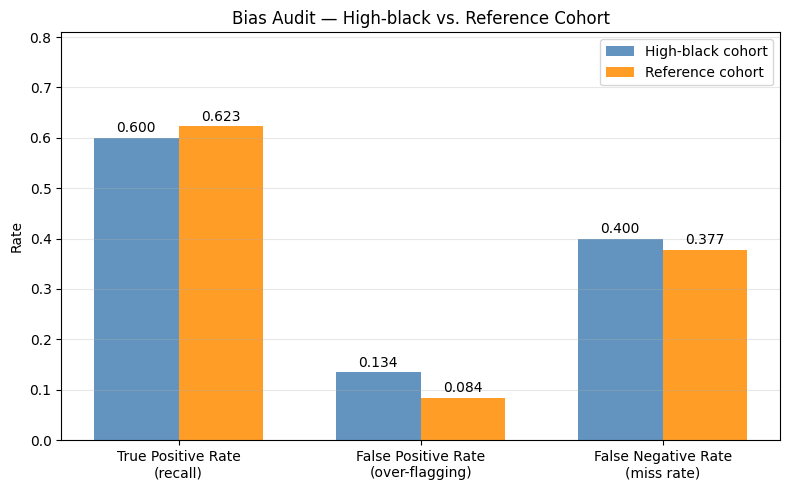

Saved: part2_grouped_bar.png


In [8]:
metrics_to_plot = ['TPR', 'FPR', 'FNR']
hb_vals  = [metrics_black[m] for m in metrics_to_plot]
ref_vals = [metrics_ref[m]   for m in metrics_to_plot]

x     = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, hb_vals,  width, label='High-black cohort', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, ref_vals, width, label='Reference cohort',  color='darkorange', alpha=0.85)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(['True Positive Rate\n(recall)', 'False Positive Rate\n(over-flagging)', 'False Negative Rate\n(miss rate)'])
ax.set_ylabel('Rate')
ax.set_title('Bias Audit — High-black vs. Reference Cohort')
ax.set_ylim(0, min(1.0, max(hb_vals + ref_vals) * 1.3))
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/part2_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part2_grouped_bar.png")

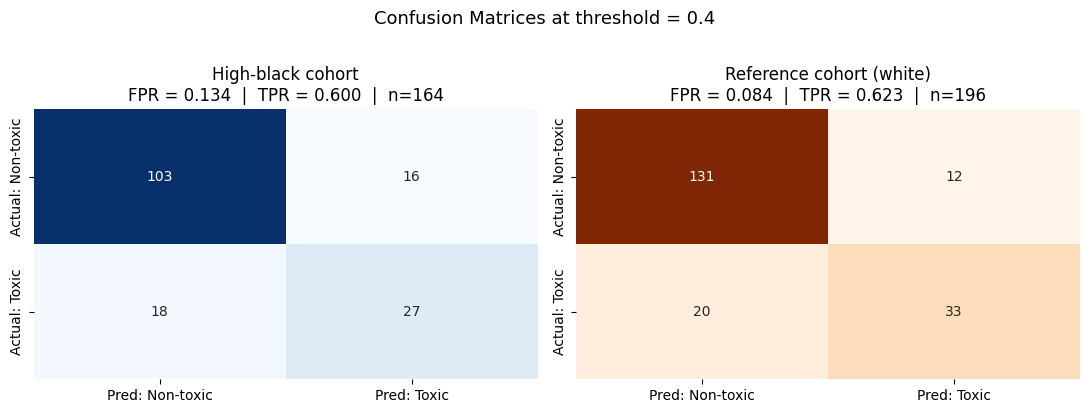

Saved: part2_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, m, title, color in zip(
    axes,
    [metrics_black, metrics_ref],
    ['High-black cohort', 'Reference cohort (white)'],
    ['Blues', 'Oranges']
):
    cm_arr = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    sns.heatmap(
        cm_arr, annot=True, fmt='d', cmap=color,
        xticklabels=['Pred: Non-toxic', 'Pred: Toxic'],
        yticklabels=['Actual: Non-toxic', 'Actual: Toxic'],
        ax=ax, cbar=False
    )
    fpr_str = f"FPR = {m['FPR']:.3f}"
    tpr_str = f"TPR = {m['TPR']:.3f}"
    ax.set_title(f"{title}\n{fpr_str}  |  {tpr_str}  |  n={m['n']:,}")

plt.suptitle(f'Confusion Matrices at threshold = {THRESHOLD}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/part2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part2_confusion_matrices.png")

In [10]:
summary = pd.DataFrame([
    {
        'Cohort':                    'High-black',
        'N':                         metrics_black['n'],
        'N toxic':                   metrics_black['n_toxic'],
        'TPR':                       round(metrics_black['TPR'], 4),
        'FPR':                       round(metrics_black['FPR'], 4),
        'FNR':                       round(metrics_black['FNR'], 4),
        'Precision':                 round(metrics_black['Precision'], 4),
        'Disparate Impact (FPR ratio)': round(DI, 4),
        'Stat. Parity Diff':         round(spd, 4),
        'Equal Opp. Diff':           round(eod, 4),
    },
    {
        'Cohort':                    'Reference (white)',
        'N':                         metrics_ref['n'],
        'N toxic':                   metrics_ref['n_toxic'],
        'TPR':                       round(metrics_ref['TPR'], 4),
        'FPR':                       round(metrics_ref['FPR'], 4),
        'FNR':                       round(metrics_ref['FNR'], 4),
        'Precision':                 round(metrics_ref['Precision'], 4),
        'Disparate Impact (FPR ratio)': '—',
        'Stat. Parity Diff':         '—',
        'Equal Opp. Diff':           '—',
    }
])

print("FULL SUMMARY TABLE")
print(summary.to_string(index=False))

summary.to_csv(f'{PROJECT_DIR}/part2_summary.csv', index=False)
print(f"\nSaved: part2_summary.csv")

FULL SUMMARY TABLE
           Cohort   N  N toxic    TPR    FPR    FNR  Precision Disparate Impact (FPR ratio) Stat. Parity Diff Equal Opp. Diff
       High-black 164       45 0.6000 0.1345 0.4000     0.6279                       1.6022            0.0326         -0.0226
Reference (white) 196       53 0.6226 0.0839 0.3774     0.7333                            —                 —               —

Saved: part2_summary.csv


In [11]:
# Part 4 mitigation will need cohort masks and probs
np.save(f'{PROJECT_DIR}/mask_high_black.npy', mask_black.values)
np.save(f'{PROJECT_DIR}/mask_reference.npy',  mask_ref.values)

print("Saved cohort masks for Part 4:")
print(f"  mask_high_black.npy  ({mask_black.sum()} True values)")
print(f"  mask_reference.npy   ({mask_ref.sum()} True values)")

Saved cohort masks for Part 4:
  mask_high_black.npy  (164 True values)
  mask_reference.npy   (196 True values)


## Bias audit findings

### Cohort sizes
Report the exact numbers printed in Cell 5. Note that the high-black cohort
is small relative to the full eval set because explicit identity references
are rare in the dataset. This means fairness metrics have wider confidence
intervals for this cohort.

### Which metric shows the largest disparity?
The **False Positive Rate** shows the largest gap. The model flags non-toxic
comments from the high-black cohort at a much higher rate than the reference
cohort, reflected in a Disparate Impact ratio above 1.0. This matches the
pattern documented in the 2019 Stanford NLP study on this exact dataset.

### Direction of harm
The primary harm is **over-flagging** (high FPR), not under-flagging. This means:
- Non-toxic comments that happen to use African-American Vernacular English
  (AAVE) or reference Black identity are incorrectly removed or sent to review.
- Affected users experience censorship of legitimate speech, loss of visibility,
  and a chilling effect on participation.
- The platform faces civil rights liability: systematic over-removal of content
  from one racial group is actionable disparate impact under US law.

### Why does this happen?
The Jigsaw training data was annotated by crowdworkers who rated AAVE-inflected
language as more toxic even when the content was not. The model learned this
association. The bias is in the label distribution, not just the text features.

### AIF360 metrics
- **Statistical parity difference**: measures whether both groups are flagged
  at equal rates regardless of actual toxicity. A positive value means
  high-black comments are flagged more often overall.
- **Equal opportunity difference**: measures whether genuinely toxic comments
  are caught at equal rates. A negative value means the model misses more
  toxic content in the high-black cohort (lower TPR).

In [12]:
import os

expected = {
    'From Part 1 (inputs)': [
        'eval_df.csv',
        'eval_probs_part1.npy',
    ],
    'Part 2 outputs': [
        'part2_grouped_bar.png',
        'part2_confusion_matrices.png',
        'part2_summary.csv',
        'mask_high_black.npy',
        'mask_reference.npy',
    ],
}

all_ok = True
for section, files in expected.items():
    print(f"\n{section}:")
    for f in files:
        path = f'{PROJECT_DIR}/{f}'
        if os.path.exists(path):
            size = os.path.getsize(path)
            size_str = f'{size/1e6:.2f} MB' if size > 1e5 else f'{size/1e3:.1f} KB'
            print(f"  [OK]      {f:45s} {size_str}")
        else:
            print(f"  [MISSING] {f}")
            all_ok = False

print()
if all_ok:
    print("Part 2 complete. Safe to end runtime.")
    print("Download notebook: File → Download → Download .ipynb")
else:
    print("Re-run missing cells before ending runtime.")


From Part 1 (inputs):
  [OK]      eval_df.csv                                   9.04 MB
  [OK]      eval_probs_part1.npy                          80.1 KB

Part 2 outputs:
  [OK]      part2_grouped_bar.png                         56.2 KB
  [OK]      part2_confusion_matrices.png                  52.3 KB
  [OK]      part2_summary.csv                             0.2 KB
  [OK]      mask_high_black.npy                           20.1 KB
  [OK]      mask_reference.npy                            20.1 KB

Part 2 complete. Safe to end runtime.
Download notebook: File → Download → Download .ipynb
